# Contents
1. Basics of channels
    - Definition
    - Unitary channels
    - Convex combinations
    - Examples of qubit channels
2. Channel Representations
    - Stinespring
    - Kraus
    - Choi
3. Equivalence of representations

# What are Channels

Channels describe ***discrete-time*** changes in systems that store quantum information. 

- Discrete-time change – change that occurs at separate, distinct time points (e.g., t = 0, 1, 2, …).
- Continuous process – change that occurs smoothly over time, at every instant (infinitesimally small time intervals).

This includes useful operatinons (such as **unitary operations** described by quantum gates and circuits) and chagnes we might wish to avoid (such as noise).

**Note**: we will be discussing channels as "abstract mathematical terms" in this lesson. *Not thinking about what is useful and what is not.*

Common names (big greek letters): $\Phi, \Psi, \Xi$ 

---

**AS A FUNCTION** (applied to density matrices)
- If a channel $\Phi$ is applied to a system, that is represtented by a density matrix $\rho$, then we obtain a system in the state $\Phi(\rho)$

## Requirements to become a channel

1. Channels are linear mappings.
2. Channels transform density matrices into density matrices.
    - **NOTE**: This includes the possibility that a channel is applied to **part of a compound system.**
  
Note: This coincides or analogous with the rule into the "simplified formulation of quantum information"

## Further details about channels
- Every channel $\Phi$ has an **input** system $X$ and an **output** system $Y$.
    - Conceptually speaking, $\Phi$ transforms $X$ to $Y$. Input and output are not considered to simultaneously co-exist. The input and output systems **DOES NOT NEED TO BE THE SAME** - they DO NOT NEED to have the same number of classical states.
    - The input and output *CAN BE* the same (i.e. $X=Y$), in which case we may simply view that $\Phi$ changes the state of this system. **This means that when $X=Y$, the channel is simply a state transformation on a single system, not a transfer between different systems.**

## Example of a channel

Suppose $Z$ is an additional system, $\Gamma$ is the classical state set of $Z$, and the pair $(Z,X)$ is in the state $\rho$. We can express $\rho$ in the following form.

$$ \rho = \sum_{a,b\in \Gamma} \ket{a}\bra{b}\otimes\rho_{a,b}$$

where $\rho_{a,b}$ is some matrix whose rows and columns correspond to whatever the classical state set of $X$ is (which is not given at this point)

Note: $\rho_{a,b}$ is not necessarily a density matrix on its own but the entire matrix $\rho$ is a density matrix.

In [2]:
import numpy as np

ketplus = np.array([[1/np.sqrt(3)], [1/np.sqrt(3)], [1/np.sqrt(3)]])
ketpsi = np.array([[np.sqrt(3)/2],[1/2]])

# say X is in the state 
X = ketplus.dot(ketplus.T)
print("X")
print(X)

# say Z is in the state
print()
Z = ketpsi.dot(ketpsi.T)
print("Z")
print(Z)

# the pair Z,X
Z_X = np.kron(Z,X)
print()
print("Z_X")
print(Z_X)

print()
gamma = [0, 1]
add = 0
gap = X.shape[0]
compose = np.zeros(Z_X.shape)
for a in gamma:
    for b in gamma:
        ket_a = np.array([[1] if a == i else [0] for i in range(2)])
        ket_b = np.array([[1] if b == i else [0] for i in range(2)])
        a_b = ket_a.dot(ket_b.T)
        p_a_b = Z_X[a*gap : a*gap+gap, b*gap : b*gap+gap]
        a_b_p_a_b = np.kron(a_b, p_a_b)
        print()
        print(a,b)
        print(a_b_p_a_b)
        compose += a_b_p_a_b

print()
print("composed matrix:")
print(compose)

X
[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]

Z
[[0.75      0.4330127]
 [0.4330127 0.25     ]]

Z_X
[[0.25       0.25       0.25       0.14433757 0.14433757 0.14433757]
 [0.25       0.25       0.25       0.14433757 0.14433757 0.14433757]
 [0.25       0.25       0.25       0.14433757 0.14433757 0.14433757]
 [0.14433757 0.14433757 0.14433757 0.08333333 0.08333333 0.08333333]
 [0.14433757 0.14433757 0.14433757 0.08333333 0.08333333 0.08333333]
 [0.14433757 0.14433757 0.14433757 0.08333333 0.08333333 0.08333333]]


0 0
[[0.25 0.25 0.25 0.   0.   0.  ]
 [0.25 0.25 0.25 0.   0.   0.  ]
 [0.25 0.25 0.25 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]]

0 1
[[0.         0.         0.         0.14433757 0.14433757 0.14433757]
 [0.         0.         0.         0.14433757 0.14433757 0.14433757]
 [0.         0.         0.         0.14433757 0.14433757 0.14433757]
 [

Applying the channel $\Phi$ to $X$ transforms it into $Y$, leaving $(Z,Y)$ in this state:
$$\sum_{a,b\in\Gamma} \ket{a}\bra{b}\otimes\Phi(\rho_{a,b}) $$

**Note: the channel is applied to a certain blocks only.**

Visually, If $\Gamma=\{0,\dots,m-1\}$ we can describe this transformation in terms of block matrices:

$$\rho=\left(\begin{matrix}
\rho_{0,0} & \dots & \rho_{0,m-1}\\
\vdots & \ddots & \vdots\\
\rho_{m-1,0} & \dots & \rho_{m-1,m-1}
\end{matrix}\right)\mapsto
\left(\begin{matrix}
\Phi(\rho_{0,0}) & \dots & \Phi(\rho_{0,m-1})\\
\vdots & \ddots & \vdots\\
\Phi(\rho_{m-1,0}) & \dots & \Phi(\rho_{m-1,m-1})
\end{matrix}\right)$$

The resulting density matrix (for every possible $Z$ and every density matrix $\rho$)

## Unitary channels
- unitary operations in simplified formulation but instead viewed as channels

Suppose $U$ is a unitary matrix representing a unitary operation on a system $X$.

**Note: In simplified formulation, we just denote this operation as matrix-vector multiplication.**

The channel $\Phi$ corresponding to this operation is defined as follows. 

$$\Phi(\rho)=UpU^\dagger $$

In mathematical terms, this is what we call **conjugation by the matrix U**.

- this is consistent that $\ket{\psi}\bra{\psi}$ being the density matrix representation of the quantum state vector $\ket{\psi}$.

- if $U$ is performed on $\ket{\psi}$, we obtain the quantum state vector $U\ket{\psi}$, whose density matrix representation is as follows:

$$ (U\ket{\psi})(U\ket{\psi})^\dagger = U\ket{\psi}\bra{\psi}U^\dagger$$

**In generality, we can express all density matrices as a convex combination of pure states.** That means this formulation works for all density matrices.

**FACT** 

This is always a valid channel. If the state of $(Z,X)$ is represented by a density matrix $\rho$ and $\Phi$ is applied to $X$, then we necessarily obtain a density matrix:

$$ (I_Z\otimes U)\space \rho\space (I_Z \otimes U)^\dagger $$

This means we can apply the unitary channel $\Phi$ to a part of a compound system.

### Example of unitary channel: Identity channel

The channel we obtain when we take $U=I$ is the identity channel:
$$ \text{Id}(\rho)=\rho $$

## Convex Combinations of Channels
- average together the channels

Let $\Phi_0$ and $\Phi_1$ be channels from $X$ to $Y$ and let $p\in[0,1]$.

- we assume both channels has same input $X$ and output $Y$

Consider applying $\Phi_0$ with probability $p$ and $\Phi_1$ with probability $1-p$. We can obtain a new channel:

$$ \Psi = p\Phi_0 + (1-p)\Phi_1 $$

- if we input $\rho$ in $\Psi$ we take the linear combination

$$ \Psi(\rho) = [p\Phi_0 + (1-p)\Phi_1]\space\rho = p\Phi_0(\rho) + (1-p)\Phi_1(\rho)$$

More generally, if $\Phi_0,\dots,\Phi_{m-1}$ are channels and $(p_0,\dots,p_{m-1})$ is a probability vector, then averaging in a similar way creates a new channel:

$$\Psi = \sum_{k=0}^{m-1} p_k\Phi_k$$

### Example of Convex Combinations of Channels: Mixed-Unitary Channels

Applying one of a collection of unitary operations to a systme yields a mixed unitary channel.

$$\Psi(\rho)=\sum_{k=0}^{m-1} p_k U_k\rho U_k^\dagger $$

Note: the set of unitary channels $U_k$ should have the same size.

**NOT EVERY CHANNEL IS A MIXED-UNITARY CHANNEL, we cannot get every channel this way. But, this is a common channel**

## Specific Examples of Channels

### Qubit reset

The *qubit reset channel* resets a qubit to the state $\ket{0}$ state.

$$ \Lambda(\rho) = \text{Tr}(\rho)\ket{0}\bra{0} $$

*Lambda symbol is pointing upward to the bloch sphere*

***NOTE: it is important to add the $\text{Tr}(\rho)$ in front, for the channel to become linear mapping.*** Keep in mind, sometimes, we need to think of channels if we apply it to a **non-density** matrix inputs. Because the smaller blocks of the entire density matrix is not a density matrix. 

### Example of Qubit Reset Applied to Compound System $\ket{\phi^+}$

Suppose $A$ and $B$ are qubits, $(A,B)$ is in the state $\ket{\phi^+}$, and $\Lambda$ is applied to $A$.

$$ \ket{\phi^+} = \frac{1}{\sqrt{2}}\ket{00}+\frac{1}{\sqrt{2}}\ket{11} $$

as a density matrix:

$$ \ket{\phi^+}\bra{\phi^+} = \left(\frac{1}{\sqrt{2}}\ket{00}+\frac{1}{\sqrt{2}}\ket{11}\right)\left(\frac{1}{\sqrt{2}}\bra{00}+\frac{1}{\sqrt{2}}\bra{11}\right)  $$

$$ \ket{\phi^+}\bra{\phi^+} = \frac{1}{2}\ket{00}\bra{00}+\frac{1}{2}\ket{00}\bra{11}+\frac{1}{2}\ket{11}\bra{00}+\frac{1}{2}\ket{11}\bra{11}$$

since,

$$ \ket{ab}\bra{cd} = (\ket{a}\otimes\ket{b})(\bra{c}\otimes\bra{d}) = \ket{a}\bra{c}\otimes\ket{b}\bra{d} $$

then, the formulation is equivalent to (from the lecture)

$$ \ket{\phi^+}\bra{\phi^+} = \frac{1}{2}\ket{0}\bra{0}\otimes\ket{0}\bra{0}+\frac{1}{2}\ket{0}\bra{1}\otimes\ket{0}\bra{1}+\frac{1}{2}\ket{1}\ket{0}\otimes\ket{1}\bra{0}+\frac{1}{2}\ket{1}\bra{1}\otimes\ket{1}\bra{1}$$

In [1]:
import numpy as np
# proof of this equality
a = 1
b = 0
c = 0
d = 1

ket_a = np.array([[1] if i == a else [0] for i in range(2)])
ket_b = np.array([[1] if i == b else [0] for i in range(2)])

ket_c = np.array([[1] if i == c else [0] for i in range(2)])
bra_c = ket_c.T
ket_d = np.array([[1] if i == d else [0] for i in range(2)])
bra_d = ket_d.T

# first formulation ket_a tensor ket_b X bra_c tensor bra_d
form1 = np.kron(ket_a, ket_b).dot(np.kron(bra_c, bra_d))
print("form 1 ketket X brabra")
print(form1)
print()

# second formulation ket_a X bra_c tensor ket_b X bra_d
form2 = np.kron(ket_a.dot(bra_c), ket_b.dot(bra_d))
print("form 2 ket X bra ket X bra")
print(form1)

form 1 ketket X brabra
[[0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]]

form 2 ket X bra ket X bra
[[0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]]


Then we can apply the channel to the first qubit, evaluate, and simplify:

$$ \frac{1}{2}\Lambda(\ket{0}\bra{0})\otimes\ket{0}\bra{0}+\frac{1}{2}\Lambda(\ket{0}\bra{1})\otimes\ket{0}\bra{1}+\frac{1}{2}\Lambda(\ket{1}\bra{0})\otimes\ket{1}\bra{0}+\frac{1}{2}\Lambda(\ket{1}\bra{1})\otimes\ket{1}\bra{1}$$

Note that $\text{Tr}(\ket{0}\bra{1}) = 0$ and $\text{Tr}(\ket{1}\bra{0}) = 0$, so we get

$$
\frac{1}{2}\ket{0}\bra{0}\otimes\ket{0}\bra{0}+
\frac{1}{2}\ket{0}\bra{0}\otimes\ket{1}\bra{1}=
\ket{0}\bra{0}\otimes\frac{I}{2}
$$

The first qubit is in state 0 while the second qubit is in the completely mixed state.

**NOTE: We did not get a $+$ state for system $B$**. You may think of this as collapsing the first qubit to 0 but remember it is a DIFFERENT BEHAVIOR since the second qubit is in completely mixed state and not $\ket{+}\bra{+}$.

### Complete Dephasing Channel

The *completely dephasing channel* zeros out off-diagonal matrix entries.


$$\Delta \begin{pmatrix} \alpha_{00} & \alpha_{01} \\ \alpha_{10} & \alpha_{11} \end{pmatrix} =\begin{pmatrix} \alpha_{00} & 0 \\ 0 & \alpha_{11}  \end{pmatrix}$$

*Delta corresponds to latin letter "D" which corresponds to "diagonal"*

Using Dirac notation,

$$ \Delta(\ket{0}\bra{0})=\ket{0}\bra{0} $$
$$ \Delta(\ket{1}\bra{0})=0 $$
$$ \Delta(\ket{0}\bra{1})=0 $$
$$ \Delta(\ket{1}\bra{1})=\ket{1}\bra{1} $$

The output is always $2\times 2$ matrix so in particular the output 0 means all 0 $2\times 2$ matrix.

### Example of Complete Dephasing Applied to Compound System $\ket{\phi^+}$

Suppose $A$ and $B$ are qubits, $(A,B)$ is in the state $\ket{\phi^+}$, and $\Delta$ is applied to $A$.

$$ \frac{1}{2}\Delta(\ket{0}\bra{0})\otimes\ket{0}\bra{0}+\frac{1}{2}\Delta(\ket{0}\bra{1})\otimes\ket{0}\bra{1}+\frac{1}{2}\Delta(\ket{1}\bra{0})\otimes\ket{1}\bra{0}+\frac{1}{2}\Delta(\ket{1}\bra{1})\otimes\ket{1}\bra{1}$$

$$=\frac{1}{2}\Delta(\ket{0}\bra{0})\otimes\ket{0}\bra{0}+\frac{1}{2}\Delta(\ket{1}\bra{1})\otimes\ket{1}\bra{1}$$

The result is **perfectly correlated pair of classical random bits**. By zeroing out the off-diagonal of a density matrix, we are *throwing away the quantum stuff* in a density matrix leaving a diagonal matrix that represents a classical probabilistic state.

Another way to think about this is that this channel represents a perfect noiseless classical channel that transmits a bit. 

So if we put a zero state or one state or a convex combination of those two states into the channel, that state comeout unchanged. 

If we put a quantum state into it, its as if the channel measures that state with a standard basis measurement and then transmits the classical result (probabilities).

### Complete Depolarizing Channel

The *complete depolarizing channel* always outputs the completely mixed state.

$$ \Omega(\rho)=\text{Tr}(\rho)\frac{I}{2} $$

- it's similar to qubit reset, except that we get a less useful completely mixed state rather than an uninitialized qubit.
- **represents an extreme form of noise**

We can describe a less extreme form of noise by averaging with the identity channel:

$$ \Omega_\epsilon = (1-\epsilon)\text{Id}+\epsilon\Omega $$

Applying to a state

$$ \Omega_\epsilon(\rho) = (1-\epsilon)(\rho)+\frac{\epsilon}{2}I $$

***NOTE: Geometrically, we can think of this as a slight contraction of the bloch sphere toward the center***

- we can also do something similar with the completely dephasing channel to model the process of decoherence for instance where things become slightly more classical through some process.

$$ \Delta_\epsilon = (1-\epsilon)\text{Id}+\epsilon\Delta $$

$$ \Delta_\epsilon\begin{pmatrix}\alpha_{00}&\alpha_{01}\\
\alpha_{10}&\alpha_{11}\end{pmatrix}=\begin{pmatrix}
\alpha_{00} & (1-\epsilon)\alpha_{01}\\(1-\epsilon)\alpha_{10}&\alpha_{11}
\end{pmatrix} $$

# Channel Representations
***IMPORTANT QUESTION:***

Linear mapping from vectors to vectors can be represented by matrices in a familiar way (which is matrix vector multiplication)... 

...but channels are linear mappings ***from matrices to matrices***.

How can we express **arbitrary channels** in mathematical terms?

Sometimes we may have a simple formula that expresses the action of a channel.

Example is the qubit reset channel $\Lambda(\rho) = \text{Tr}(\rho)\ket{0}\bra{0}$, but ***THIS IS NOT PRACTICAL IN GENERAL because there won't always be such a nice formula.*** 

In comparison, in the simplified formulation of quantum information, we use **unitary matrices** to represent operations on quantum state vectors. Every unitary matrix represents a valid operation and every valid operation can be expressed as a unitary matrix. 

So, ***how do we do this for channels???***

## Three ways to represent channels
1. Stinespring representations
2. Kraus representations
3. Choi representations

**Note: These representations relate to each other.** These representations precisely capture the requirements we have on channels which are:
- linear mappings
- transform density matrices to density matrices even if they are applied to a part of a compound system

## Stinespring representations
Every channel can be implemented in the following way:
1. Form a compound system including the **input system** and an initialized **workspace system**.
2. Perform a **unitary operation** on the compound systems.
3. **Discard** everything except the output system.

It is helpful to discuss this in terms of diagram, where we start with **the input system and output system are the same.**
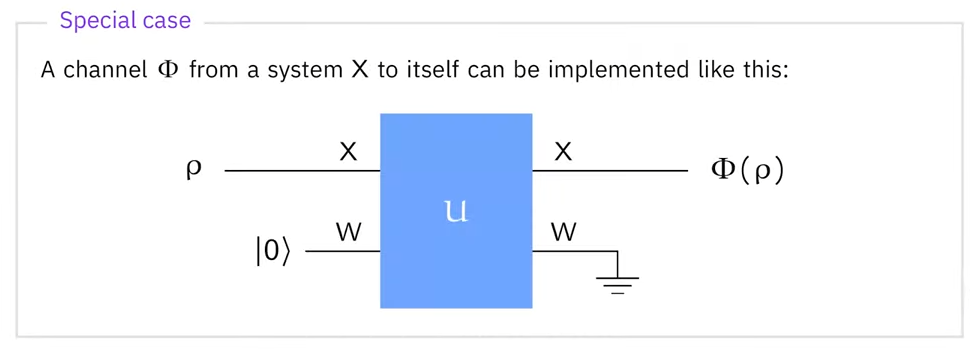

This diagram is similar to a quantum circuit diagram, except that the wires represent arbitrary systems and not necessarily single qubits.

- we start with the input system $X$ being in some state $\rho$
- we initialize some workspace system $W$, and we assume in the diagram that 0 is the classical state of $W$, so $\ket{0}$ will be taken as the initialized state of the system, but we could alternatively fix any pure state of $W$ and view that as the initialized state
- we then perform some unitary operation on the pair $(W,X)$
- we then trace out the workspace system and output $X$

**Note: ground symbol means "being discarded"**. Not conventional, in qiskit just ignore the workspace system or qubits that we are not interested in.

In general, we ***DO NOT NEED the input system and output system to be the same.***. We can have for instance output system $Y$ along with a garbage system $G$ that gets traced out. 
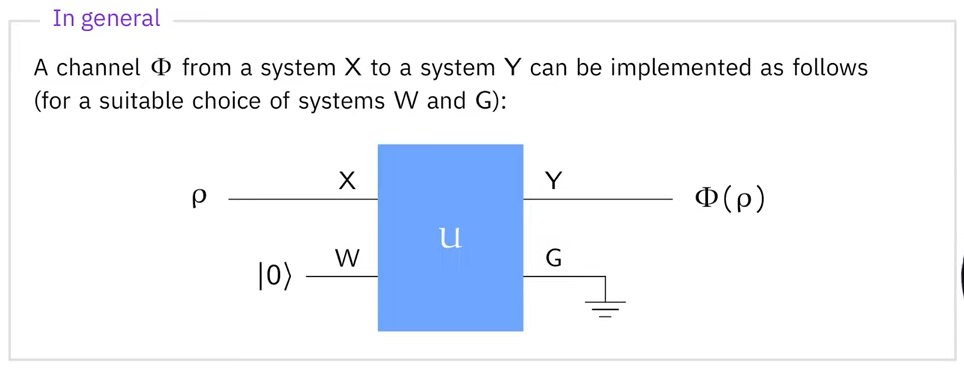

**In order for $U$ to be unitary, it has to be a square matrix.** So there is an assumption here that the **pair $(G,Y)$, together has the same number of classical states as the pair $(W,X)$.**

For example, maybe these systems consist of qubits and the input system $X$ consists of 5 qubits and $W$ consists of 10 qubits. **So $U$ is a unitary operation on 15 qubits.** 

If $Y$ consists of 4 qubits, that means $G$ consists of 11 qubits. OR maybe these **ARE NOT qubits at all**

***All that is important, $W$ and $X$ together and $G$ and $Y$ together have the same number of classical states so that $U$ can be a unitary.***

Any mapping $\Phi$ that can be described in this way is in fact a valid channel. In particular, if we start with the density matrix and then tack on an additional workspace system, then we will certainly be left with a density matrix we already observed that applying a unitary operation gives us a valid channel and if we have a density matrix of a compound and we trace out one of the systems, then again we will be left with a density matrix. When we compose these steps, we'll be guaranteed that it always transforms density matrices into density matrices and also linear. 

***At this point, it is NOT YET CLEAR that any channel can indeed be implemented in this way for some choice workspace system and garbage system as well as the unitary operation $U$. We will see why at the end of the lesson.***

### Example of Stinespring representation for dephasing.

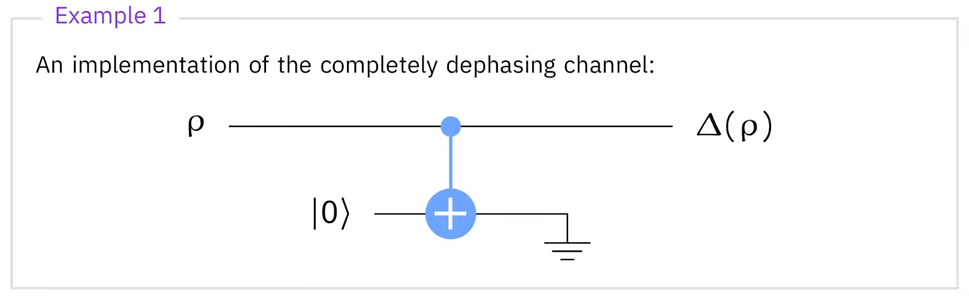
In this diagram, the wires are qubits and this is an ordinary CNOT gate. The input qubit is on the top and the workspace is initialized to $\ket{0}$. We then apply CNOT; the control is the input qubit while the target is the workspace qubit. Then, the workspace qubit is traced out. 

*Intuitively, the CNOT gate kind of acts like a standard basis measurent on the top qubit by copying its classical state onto the bottom qubit. Then the result gets thrown away*.

Calculating this mathematically,
- first write down the initial states
  
$$ \ket{0}\bra{0}\otimes\rho = 
\begin{pmatrix}
\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} & 0 & 0\\
\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1} & 0 & 0\\
0 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
\end{pmatrix} $$

- apply the CNOT gate as a unitary channel, which is $CNOT_{01}(\ket{0}\bra{0}\otimes\rho)CNOT_{01}^\dagger$

$$ 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 0 & 1\\
0 & 0 & 1 & 0\\
0 & 1 & 0 & 0\\
\end{pmatrix}
\begin{pmatrix}
\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} & 0 & 0\\
\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1} & 0 & 0\\
0 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
\end{pmatrix}
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 0 & 1\\
0 & 0 & 1 & 0\\
0 & 1 & 0 & 0\\
\end{pmatrix}$$

- the result is
  
$$
\begin{pmatrix}
\bra{0}\rho\ket{0} & 0 & 0 & \bra{0}\rho\ket{1}\\
0 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
\bra{1}\rho\ket{0} & 0 & 0 & \bra{1}\rho\ket{1}\\
\end{pmatrix}
$$

- in dirac notation,

$$ 
\bra{0}\rho\ket{0}\ket{0}\bra{0}\otimes\ket{0}\bra{0} +
\bra{0}\rho\ket{1}\ket{0}\bra{1}\otimes\ket{0}\bra{1} +
\bra{1}\rho\ket{0}\ket{1}\bra{0}\otimes\ket{1}\bra{0} +
\bra{1}\rho\ket{1}\ket{1}\bra{1}\otimes\ket{1}\bra{1}$$

- then we get the partial trace, *remember the $\text{Tr}_A(M\otimes N)=\text{Tr}(M)N$*
$$ 
\bra{0}\rho\ket{0} \text{Tr}(\ket{0}\bra{0})\otimes\ket{0}\bra{0} +
\bra{0}\rho\ket{1} \text{Tr}(\ket{0}\bra{1})\otimes\ket{0}\bra{1} +
\bra{1}\rho\ket{0} \text{Tr}(\ket{1}\bra{0})\otimes\ket{1}\bra{0} +
\bra{1}\rho\ket{1} \text{Tr}(\ket{1}\bra{1})\otimes\ket{1}\bra{1}$$

$$ =
\bra{0}\rho\ket{0} \space\ket{0}\bra{0} +
\bra{1}\rho\ket{1} \space\ket{1}\bra{1} = \Delta(\rho)$$


In [32]:
import numpy as np

ket_minus = np.array([[1],[-1]]) * (1/np.sqrt(2))
rho_minus = ket_minus.dot(ket_minus.T)
ket_0 = np.array([[1],[0]])
rho_0 = ket_0.dot(ket_0.T)

rho_0_minus = np.kron(rho_0, rho_minus)
print('rho')
print(rho_minus)

print()
print('rho with workspace')
print(rho_0_minus)

CNOT = np.array([
    [1,0,0,0],
    [0,0,0,1],
    [0,0,1,0],
    [0,1,0,0]
])

res_rho = CNOT.dot(rho_0_minus.dot(CNOT))
print()
print('rho after CNOT')
print(res_rho)
print()

# partial trace
traced_p = np.zeros((2,2))
for i in range(2):
    ket_i = np.array([[1] if i==j else [0] for j in range(2)])
    left = np.kron(np.identity(2), ket_i.T)
    right = np.kron(np.identity(2), ket_i)
    traced_p += left.dot(res_rho.dot(right))

print("rho after trace")
print(traced_p)
print("which is equivalent to the resulting state after we applied a dephasing channel")

rho
[[ 0.5 -0.5]
 [-0.5  0.5]]

rho with workspace
[[ 0.5 -0.5  0.  -0. ]
 [-0.5  0.5 -0.   0. ]
 [ 0.  -0.   0.  -0. ]
 [-0.   0.  -0.   0. ]]

rho after CNOT
[[ 0.5  0.   0.  -0.5]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [-0.5  0.   0.   0.5]]

rho after trace
[[0.5 0. ]
 [0.  0.5]]
which is equivalent to the resulting state after we applied a dephasing channel


Another way of representing the dephasing channel is:

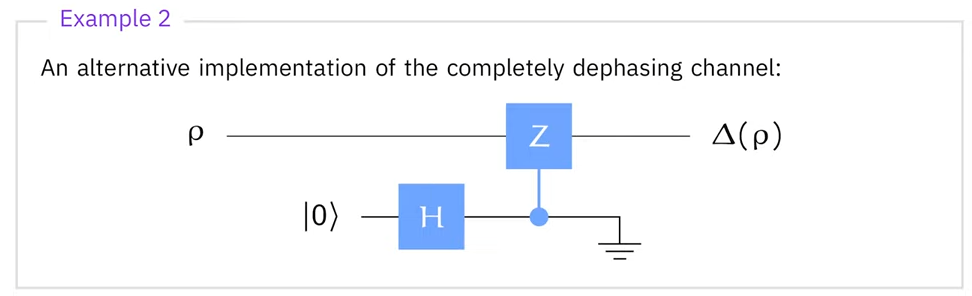

In [66]:
import numpy as np

ket_minus = np.array([[1],[-1]]) * (1/np.sqrt(2))
rho_minus = ket_minus.dot(ket_minus.T)
ket_0 = np.array([[1],[0]])
rho_0 = ket_0.dot(ket_0.T)

print('rho')
print(rho_minus)

rho_0_minus = np.kron(rho_0, rho_minus)
print()
print('rho with workspace')
print(rho_0_minus)

H = 1/np.sqrt(2) * np.array([[1,1],[1,-1]])
H_I = np.kron(H, np.identity(2))

res_rho = H_I.dot(rho_0_minus.dot(H_I))
print()
print('rho after H_I')
print(res_rho)
print()

Z = np.array([[1,0],[0,-1]])
ket_1 = np.array([[0],[1]])
rho_1 = ket_1.dot(ket_1.T)
CZ = np.kron(rho_0, np.identity(2)) + np.kron(rho_1, Z)
res_rho = CZ.dot(res_rho.dot(CZ))
print()
print('rho after CZ')
print(res_rho)
print()

# partial trace
traced_p = np.zeros((2,2))
for i in range(2):
    ket_i = np.array([[1] if i==j else [0] for j in range(2)])
    left = np.kron(np.identity(2), ket_i.T)
    right = np.kron(np.identity(2), ket_i)
    traced_p += left.dot(res_rho.dot(right))
    print("tracing...", i)
    print(left.dot(res_rho.dot(right)))
    print()

print("rho after trace")
print(traced_p)
print("which is equivalent to the resulting state after we applied a dephasing channel")

rho
[[ 0.5 -0.5]
 [-0.5  0.5]]

rho with workspace
[[ 0.5 -0.5  0.  -0. ]
 [-0.5  0.5 -0.   0. ]
 [ 0.  -0.   0.  -0. ]
 [-0.   0.  -0.   0. ]]

rho after H_I
[[ 0.25 -0.25  0.25 -0.25]
 [-0.25  0.25 -0.25  0.25]
 [ 0.25 -0.25  0.25 -0.25]
 [-0.25  0.25 -0.25  0.25]]


rho after CZ
[[ 0.25 -0.25  0.25  0.25]
 [-0.25  0.25 -0.25 -0.25]
 [ 0.25 -0.25  0.25  0.25]
 [ 0.25 -0.25  0.25  0.25]]

tracing... 0
[[0.25 0.25]
 [0.25 0.25]]

tracing... 1
[[ 0.25 -0.25]
 [-0.25  0.25]]

rho after trace
[[0.5 0. ]
 [0.  0.5]]
which is equivalent to the resulting state after we applied a dephasing channel


Note that we get this after tracing but before we sum:

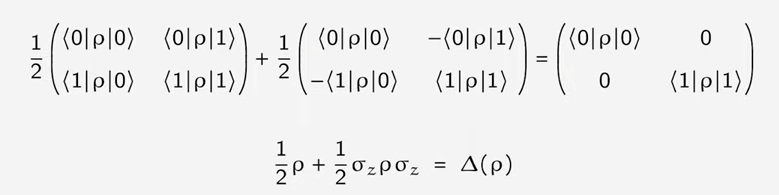

If we average a given density matrix with that density matrix conjugated by the pauli Z matrix, then that is the dephasing channel.



In [79]:
import numpy as np

ket_minus = np.array([[1],[-1]]) * (1/np.sqrt(2))
rho = ket_minus.dot(ket_minus.T)

print('rho')
print(rho)
print()

Z = np.array([[1,0],[0,-1]])
print("mixed unitary channel - mix of Id and Z")
print((1/2) * rho + (1/2) * Z.dot(rho.dot(Z)))
print("which is equivalent to the resulting state after we applied a dephasing channel")

rho
[[ 0.5 -0.5]
 [-0.5  0.5]]

mixed unitary channel - mix of Id and Z
[[0.5 0. ]
 [0.  0.5]]
which is equivalent to the resulting state after we applied a dephasing channel


Given that we obtained two representations from the example, this means that ***Stinespring representations are not unique***. In fact, there are ***infinitely many of them for a given channel.***

## Kraus Representations

*Kraus representations* are a convenient formulaic way of expressing channels **through matrix multiplication and addition.**

In general, a Kraus representation of a channel $\Phi$ looks like this:

$$ \Phi(\rho)=\sum_{k=0}^{N-1}A_k\rho A_k^\dagger $$

Here $A_0,\dots,A_{N-1}$ are matrices (called Kraus matrices in this context) that all have the same dimensions:
- The columns of $A_0,\dots,A_{N-1}$ correspond to the classical states of the input system.
- The rows of $A_0, \dots, A_{N-1}$ correspond to the classical states of the output system.

**Note: all Kraus matrices have the same dimension**. We conjugate $\rho$ to each of these matrices and sum up the results. 

If we take the product $A_k\rho A_k^\dagger$, for any choice of $k$, we get a square matrix, whose rows and columns correspond to the classical states of the output system. So, the expression produces a density matrix of the output system.

Example. 
- $A$ has a size of $d_{out}\times d_{in}$.
- $\rho$ has a size of $d_{in}\times d_{in}$.
- $A^\dagger$ has a size of $d_{in}\times d_{out}$.
- $A\rho$ will have a size of $d_{out}\times d_{in}$
- $A\rho A^\dagger$ will have a size of $d_{out}\times d_{out}$

***IT IS NOT THE CASE that for an arbitrary choice of these Kraus matrices that we get a valid channel.*** There is a condition on the matrices that guarantees that we will get a valid channel and that condition is:

$$\sum_{k=0}^{N-1} A_k^\dagger A_k = I $$

**Note: the rows and columns of the identity matrix matches the classical state of the input system.**

*It turns out every channel does in fact have a representation that takes this form as long as we take N to be large enough.* 

### Example of Kraus representation for qubit reset channel

We can obtain a Kraus representation of the qubit reset channel by using two Kraus matrices $A_0=\ket{0}\bra{0}$ and $A_1=\ket{0}\bra{1}$.

This means $N=2$ for this example.

$$ \sum_{k=0}^1 A_k\rho A_k^\dagger = \ket{0}\bra{0}\rho\ket{0}\bra{0}+\ket{0}\bra{1}\rho\ket{1}\bra{0} $$

- using distributive property

$$ \sum_{k=0}^1 A_k\rho A_k^\dagger = (\bra{0}\rho\ket{0}+\bra{1}\rho\ket{1})\ket{0}\bra{0} $$
$$ = \text{Tr}(\rho)\ket{0}\bra{0} $$

This is exactly the qubit reset channel. Now we check if we meet the condition

$$ \sum_{k=0}^1 A_k A_k^\dagger = I $$

$$ \sum_{k=0}^1 A_k A_k^\dagger = \ket{0}\braket{0|0}\bra{0} + \ket{1}\braket{0|0}\bra{1} $$

$$ \sum_{k=0}^1 A_k A_k^\dagger = \ket{0}\bra{0} + \ket{1}\bra{1} = I $$

Therefore, this is a valid Kraus representation.

### Example of Kraus representation for completely dephasing channel.

We can obtain a Kraus representation of the completely dephasing channel by taking $A_0=\ket{0}\bra{1}$ and $A_1=\ket{1}\bra{1}$

$$\sum_{k=0}^1 A_k\rho A_k^\dagger = \ket{0}\bra{0}\rho\ket{0}\bra{0}+\ket{1}\bra{1}\rho\ket{1}\bra{1}$$

- $\bra{a}\rho\ket{a}$ is a scalar so,

$$\sum_{k=0}^1 A_k\rho A_k^\dagger = \bra{0}\rho\ket{0}\space\ket{0}\bra{0}+\bra{1}\rho\ket{1}\space\ket{1}\bra{1}$$
$$= \Delta(\rho)$$

- Checking the requirement

$$\sum_{k=0}^1 A_k A_k^\dagger = \ket{0}\braket{0|0}\bra{0} + \ket{1}\braket{1|1}\bra{1}$$

$$ = \ket{0}\bra{0} + \ket{1}\bra{1} = I$$

### Alternative Kraus representation for completely dephasing channel.

We can obtain a different Kraus representation of the completely dephasing channel by taking $A_0=\frac{I}{\sqrt{2}}$ and $A_1=\frac{\sigma_z}{\sqrt{2}}$

- this is inferred from the discussion of Stinespring representation

$$\sum_{k=0}^1 A_k\rho A_k^\dagger = \frac{I}{\sqrt{2}}\rho\frac{I}{\sqrt{2}}+\frac{\sigma_z}{\sqrt{2}}\rho\frac{\sigma_z}{\sqrt{2}} $$

$$ = \frac{1}{2}\rho+\frac{1}{2}\sigma_z\rho\sigma_z $$

$$ = \Delta(\rho)$$

- checking the condition

$$ \sum_{k=0}^1 A_k A_k^\dagger = \frac{I}{\sqrt{2}}\frac{I}{\sqrt{2}}+\frac{\sigma_z}{\sqrt{2}}\frac{\sigma_z}{\sqrt{2}} = \frac{I}{2}+\frac{I}{2} = I$$

### Example of Kraus representation for completely depolarizing channel

- 4 Kraus matrices (or more) are needed
- one option is to use the following matrices.

$$ A_0 = \frac{\ket{0}\bra{0}}{\sqrt{2}} $$

$$ A_1 = \frac{\ket{0}\bra{1}}{\sqrt{2}} $$

$$ A_2 = \frac{\ket{1}\bra{0}}{\sqrt{2}} $$

$$ A_3 = \frac{\ket{1}\bra{1}}{\sqrt{2}} $$

- so $N=4$ in the given matrices

$$ \sum_{k=0}^{N=4} A_k\rho A_k^\dagger = 
\frac{\ket{0}\bra{0}}{\sqrt{2}}\rho\frac{\ket{0}\bra{0}}{\sqrt{2}}+
\frac{\ket{0}\bra{1}}{\sqrt{2}}\rho\frac{\ket{1}\bra{0}}{\sqrt{2}}+
\frac{\ket{1}\bra{0}}{\sqrt{2}}\rho\frac{\ket{0}\bra{1}}{\sqrt{2}}+
\frac{\ket{1}\bra{1}}{\sqrt{2}}\rho\frac{\ket{1}\bra{1}}{\sqrt{2}}
$$

$$ = \frac{1}{2}\left[\space
\ket{0}\bra{0} (\bra{0}\rho\ket{0}+\bra{1}\rho\ket{1})+
\ket{1}\bra{1} (\bra{0}\rho\ket{0}+\bra{1}\rho\ket{1})
\space
\right]
$$

$$ = \frac{1}{2}\left[\space
\text{Tr}(\rho)\ket{0}\bra{0} +
\text{Tr}(\rho)\ket{1}\bra{1} 
\space
\right]
$$

$$ = \text{Tr}(\rho)\frac{1}{2}\left[\space
\ket{0}\bra{0} +
\ket{1}\bra{1} 
\space
\right]
$$

$$ = \text{Tr}(\rho)\frac{I}{2} = \Omega(\rho)
$$

- checking the condition

$$ \sum_{k=0}^{N=4} A_k A_k^\dagger = 
\frac{\ket{0}\bra{0}}{\sqrt{2}}\frac{\ket{0}\bra{0}}{\sqrt{2}}+
\frac{\ket{0}\bra{1}}{\sqrt{2}}\frac{\ket{1}\bra{0}}{\sqrt{2}}+
\frac{\ket{1}\bra{0}}{\sqrt{2}}\frac{\ket{0}\bra{1}}{\sqrt{2}}+
\frac{\ket{1}\bra{1}}{\sqrt{2}}\frac{\ket{1}\bra{1}}{\sqrt{2}}
$$

$$ = 
\frac{\ket{0}\bra{0}}{2}+
\frac{\ket{0}\bra{0}}{2}+
\frac{\ket{1}\bra{1}}{2}+
\frac{\ket{1}\bra{1}}{2} =
\ket{0}\bra{0} + \ket{1}\bra{1} = I
$$

### Alternative Kraus representation for completely depolarizing channel

- using the following matrices:

$$ A_0 = \frac{I}{2} $$

$$ A_1 = \frac{\sigma_x}{2} $$

$$ A_2 = \frac{\sigma_y}{2} $$

$$ A_3 = \frac{\sigma_z}{2} $$

- applying these matrices

$$ \sum_{k=0}^{N=4} A_k\rho A_k^\dagger = 
\frac{I}{2}\rho\frac{I}{2}+
\frac{\sigma_x}{2}\rho\frac{\sigma_x}{2}+
\frac{\sigma_y}{2}\rho\frac{\sigma_y}{2}+
\frac{\sigma_z}{2}\rho\frac{\sigma_z}{2}
$$

$$ = 
\frac{\rho+
\sigma_x\rho\sigma_x+
\sigma_y\rho\sigma_y+
\sigma_z\rho\sigma_z}{4}
$$

- given that $\rho = \begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}0 & 1\\1& 0 \end{pmatrix}\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}\begin{pmatrix}0 & 1\\1& 0 \end{pmatrix}+
\begin{pmatrix}0 & -i\\i& 0 \end{pmatrix}\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}\begin{pmatrix}0 & -i\\i& 0 \end{pmatrix}+
\begin{pmatrix}1 & 0\\0 & -1 \end{pmatrix}\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}\begin{pmatrix}1 & 0\\0 & -1 \end{pmatrix}}{4}
$$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}0 & 1\\1& 0 \end{pmatrix}
\begin{pmatrix}\bra{0}\rho\ket{1} & \bra{0}\rho\ket{0} \\ \bra{1}\rho\ket{1} & \bra{0}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}0 & -i\\i& 0 \end{pmatrix}
\begin{pmatrix}i\bra{0}\rho\ket{1} & -i\bra{0}\rho\ket{0} \\ i\bra{1}\rho\ket{1} & -i\bra{0}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}1 & 0\\0 & -1 \end{pmatrix}\begin{pmatrix}\bra{0}\rho\ket{0} & -\bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & -\bra{1}\rho\ket{1}\end{pmatrix}}{4}
$$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & \bra{0}\rho\ket{1} \\ \bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}-i^2\bra{1}\rho\ket{1} & i^2\bra{0}\rho\ket{1} \\ i^2\bra{0}\rho\ket{1} & -i^2\bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{0}\rho\ket{0} & -\bra{0}\rho\ket{1} \\ -\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}}{4}
$$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & \bra{0}\rho\ket{1} \\ \bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}-i^2\bra{1}\rho\ket{1} & i^2\bra{0}\rho\ket{1} \\ i^2\bra{0}\rho\ket{1} & -i^2\bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{0}\rho\ket{0} & -\bra{0}\rho\ket{1} \\ -\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}}{4}
$$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & \bra{0}\rho\ket{1} \\ \bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & -\bra{0}\rho\ket{1} \\ -\bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{0}\rho\ket{0} & -\bra{0}\rho\ket{1} \\ -\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}}{4}
$$

$$ = 
\frac{\begin{pmatrix}\bra{0}\rho\ket{0} & \bra{0}\rho\ket{1} \\ \bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & \bra{0}\rho\ket{1} \\ \bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{1}\rho\ket{1} & -\bra{0}\rho\ket{1} \\ -\bra{0}\rho\ket{1} & \bra{0}\rho\ket{0}\end{pmatrix}+
\begin{pmatrix}\bra{0}\rho\ket{0} & -\bra{0}\rho\ket{1} \\ -\bra{1}\rho\ket{0} & \bra{1}\rho\ket{1}\end{pmatrix}}{4}
$$

$$ = 
\frac{
\begin{pmatrix}
\bra{0}\rho\ket{0} + \bra{1}\rho\ket{1} + \bra{1}\rho\ket{1} + \bra{0}\rho\ket{0} & 
\bra{0}\rho\ket{1} + \bra{0}\rho\ket{1} - \bra{0}\rho\ket{1} - \bra{0}\rho\ket{1} \\ 
\bra{1}\rho\ket{0} + \bra{0}\rho\ket{1} - \bra{0}\rho\ket{1} - \bra{1}\rho\ket{0} & 
\bra{1}\rho\ket{1} + \bra{0}\rho\ket{0} + \bra{0}\rho\ket{0} + \bra{1}\rho\ket{1}
\end{pmatrix}}{4}
$$

$$ = 
\frac{
\begin{pmatrix}
2 \bra{0}\rho\ket{0} + 2 \bra{1}\rho\ket{1}& 
0 \\ 
0 & 
2 \bra{1}\rho\ket{1} + 2 \bra{0}\rho\ket{0} 
\end{pmatrix}}{4}
$$

$$ = 
\frac{1}{2}
\begin{pmatrix}
\bra{0}\rho\ket{0} + \bra{1}\rho\ket{1}& 
0 \\ 
0 & 
\bra{1}\rho\ket{1} + \bra{0}\rho\ket{0} 
\end{pmatrix}
$$

$$ = 
\frac{1}{2}
\text{Tr}(\rho)
\begin{pmatrix}
1& 
0 \\ 
0 & 
1
\end{pmatrix}
$$

$$ = 
\text{Tr}(\rho)
\frac{I}{2} = \Omega(\rho)
$$

- checking the condition

$$ \sum_{k=0}^{3} A_k^\dagger A_k = \frac{I}{2}\frac{I}{2} + \frac{\sigma_x}{2}\frac{\sigma_x}{2} + \frac{\sigma_y}{2}\frac{\sigma_y}{2} + \frac{\sigma_z}{2}\frac{\sigma_z}{2}$$

$$ = \frac{I+I+I+I}{4}=\frac{4I}{4}=I$$

## Choi Representations

The *Choi representation* of a channel $\Phi$ is a single matrix denoted $J(\Phi)$.

If the input system has $n$ classical states and the output system has $m$ classical states, then $J(\Phi)$ is an $nm\times nm $ matrix (square).

Before defining how the matrix is defined, here are some key properties of this representation which motivate the representation in a way that the actual definition itself might not at least on the surface.

### Key properties of Choi Representation

1. Choi representation is a ***faithful*** representation; for two channels $\Phi$ and $\Psi$ we have $J(\Phi)=J(\Psi)$ if and only if $\Phi=\Psi$. This means every channel has only one choi representation.
   - This also means the two channels are the same if and only if their Choi representations are the same.
   - If you have two descriptions of channels, such as two Stinespring or Kraus representations, and you want to know if they are in face the same channel, you can just compute the Choi representation and check whether or not they are equal
2. Simple-to-check conditions on $J(\Phi)$ are true if and only if $\Phi$ is a valid channel.
   - this is also true for all the representations; nothing fancy
   - to be discussed in more detail

***Remark: The matrix $J(\Phi)$ does not directly represent $\Phi$ as a linear mapping. (The action of $\Phi$ can, however, be recovered from $J(\Phi)$ by a simple formula.)*** It's more natural to associate the Choi representation with the density matrix that represents a certain state than it is to think about the Choi representation as describing a linear mapping. It is however possible to recover the action of the channel from its Choi representation using a simple formula but it's not so simple as ordinary matrix multiplication. 

- “Recovering the action” just means:
  - from the Choi matrix alone, you can compute the channel output $\Phi(\rho)$ for any input $\rho$, so the matrix fully specifies the channel.

### Definition of Choi Representation

Let $\Phi$ be a channel from a system $X$ to a sytem $Y$, and assume the classical state set of the input system $X$ is $\Sigma$.

*no need to refer the classical state set of $Y$ since it is not necessary for the definition*

The choi representation of $\Phi$ is defined as follows:

$$J(\Phi)=\sum_{a,b\in\Sigma}\ket{a}\bra{b}\otimes\Phi(\ket{a}\bra{b}) $$

- there are a couple of different ways to think about this formula
- sometimes, the choi representation is defined in a slightly different way where the ordering of the tensor factors is reversed. (the $\Phi$ is applied to the first tensor factors)
- this format is using the qiskit conventions
- this is also better for describing the representation visually in terms of block matrices, so this is the one we are going to go


If we assume $\Sigma=\{0,\dots,n-1\}$, then we can express $J(\Phi)$ as a block matrix:

$$ J(\Phi)=
\begin{pmatrix}
\Phi(\ket{0}\bra{0}) & \Phi(\ket{0}\bra{1}) & \dots & \Phi(\ket{0}\bra{n-1}) \\
\Phi(\ket{1}\bra{0} & \Phi(\ket{1}\bra{1}) & \dots & \Phi(\ket{1}\bra{n-1})) \\
\vdots & \vdots & \ddots & \vdots \\
\Phi(\ket{n-1}\bra{0}) & \Phi(\ket{n-1}\bra{1}) & \dots & \Phi(\ket{n-1}\bra{n-1})
\end{pmatrix} $$

- the choi representation of $\Phi$ is the matrix we get by evaluating $\Phi$ on each of the **block matrices that have exaclty one entry** and all of the entries are 0
- then arrange them in a natural way to form the matrix

**NOTE: It may not be clear why we need to form a matrix like this, but it turns out to be useful**

The set $\{\ket{a}\bra{b} : 0\leq a,b < n\}$ forms a basis for the spacec of all $n\times n$ complex matrices.

The blocks of $J(\Phi)$ determine the action of $\Phi$ on all $n\times n$ matrices.

**NOTE: If you have the $J(\rho)$ matrix, then you can certainly determine what $\Phi$ does on arbitrary $n\times n$ matrix by linearity. Specifically, by taking appropriate linear combination of the Blocks**

- Matrix $J(\Phi)$ does in fact uniquely determine $\Phi$ as a linear mapping.

### Another way of thinking Choi representation

- another way of thinking this choi representation is that it represents a state as a density matrix when it's normalized specifically by dividing it by the number of classical states of the input system
- in other words if we normalize the Choi representation $J(\Phi)$ of a channel $\Phi$ by dividing by $n=|\Sigma|$, we obtain a density matrix. This state is called the ***Choi state*** of $\Phi$

Imagine that we have two identical copies of the input system and we consider the quantum state vector:

$$ \ket{\psi}=\frac{1}{\sqrt{n}}\sum_{a\in\Sigma} \ket{a}\otimes\ket{a} $$

- this represents a maximally entangled state of this pair of identical systems

Then obtain the density matrix by multiplying its conjugate transpose:

$$\ket{\psi}\bra{\psi}=\frac{1}{n}\sum_{a,b\in\Sigma} \ket{a}\bra{b} \otimes \ket{a}\bra{b}$$

- if we think about the Choi representation of the channel divided by $n$, then we see that it's the state that we would obtain if we were to apply the channel $\Phi$ to the second system

$$\frac{1}{n}J(\Phi)=\frac{1}{n}\sum_{a,b\in\Sigma} \ket{a}\bra{b}\otimes\Phi(\ket{a}\bra{b})$$

In a figure, it looks something likes this:
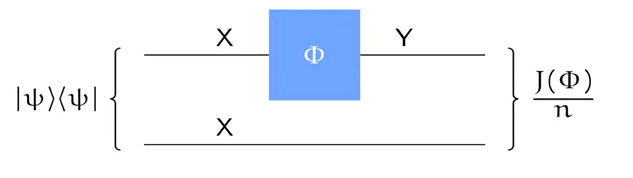

- we have two copies of system $X$ in this maximally entangled state $\psi$
- the channel $\Phi$ is applied to second system which is one on the top of the diagram
- the resulting state is the Choi state of $\Phi$

***NOTE: we would NOT normally name two systems with the same name like this, it's generally not helpful to give the same name to two different things but it does make sense in this case to make connection with Choi representation***

### Implications of thinking Choi representation this way
1. $J(\Phi)/n$ is a density matrix - and therefore $J(\Phi)\geq0$
   - remember that we place a requirement on channels that it should transform density matrices to density matrices
   - again since choi state is using the channel itself, it maps this into a density matrix, this is a special case
2. Tracing out the sytem $Y$ from $J(\Phi)/n$ leaves the completely mixed state on $X$.

$$ \text{Tr}_Y\left(\frac{J(\Phi)}{n}\right)=\frac{I_X}{n} $$

- because applying a channel to a system and then throwing the resulting system to the garbage is equivalent to just throwing the original system to the garbage 
- if we are to do that to our maximally entangled state, we'd be left with a density matrix divided by $n$ or in other words the completely mixed state for the system $X$
- the idea in more mathematical terms, is that composing any channel with the trace on the output system must be equal to the trace on the input system and that's because channels must preserve trace by virtue of the fact that linear mappings that always transform density matrices to density matrices

If we clear the denominator $n$ on both sides, we get

$$ \text{Tr}_Y(J(\Phi))=I_X $$

- a slightly cleaner condition
- in words, performing the partial trace on the output system of the Choi representation of a channel must give us the identity matrix on the input system

In summary:
- choi representations of channels are always positive semi-definite
- if we trace out the output system we're necessarily left with the identity matrix on the input system

These conditions on $J(\Phi)$ turn out to be *necessary and sufficient* for $\Phi$ to be a channel

### Example of Choi representation for the completely dephasing channel 

$$ J(\Delta) = \sum_{a,b=0}^1\ket{a}\bra{b}\otimes\Delta(\ket{a}\bra{b}) $$

$$ = \sum_{a,b=0}^1\ket{0}\bra{0}\otimes\Delta(\ket{0}\bra{0})+
\ket{0}\bra{1}\otimes\Delta(\ket{0}\bra{1})+
\ket{1}\bra{0}\otimes\Delta(\ket{1}\bra{0})+
\ket{1}\bra{1}\otimes\Delta(\ket{1}\bra{1})$$

- remember $\Delta$ channel zeros out the non-diagonal entries

$$ = \sum_{a,b=0}^1\ket{0}\bra{0}\otimes\Delta(\ket{0}\bra{0})+
\ket{1}\bra{1}\otimes\Delta(\ket{1}\bra{1})$$

$$ = \sum_{a,b=0}^1\ket{0}\bra{0}\otimes\ket{0}\bra{0}+
\ket{1}\bra{1}\otimes\ket{1}\bra{1}$$


- viewing this as a block matrix:

$$ J(\Delta) = \begin{pmatrix}
\Delta\begin{pmatrix}1&0\\0&0\end{pmatrix} &
\Delta\begin{pmatrix}0&1\\0&0\end{pmatrix} \\
\Delta\begin{pmatrix}0&0\\1&0\end{pmatrix} &
\Delta\begin{pmatrix}0&0\\0&1\end{pmatrix}
\end{pmatrix} = 
\begin{pmatrix}
1&0&0&0\\
0&0&0&0\\
0&0&0&0\\
0&0&0&1
\end{pmatrix}
$$

In [15]:
# checking the condition

import numpy as np

J_D = np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,1]])

# trace out second system
res = np.zeros((2,2))
for i in range(2):
    ket_i = np.array([[1] if i == j else [0] for j in range(2)])
    left = np.kron(np.identity(2), ket_i.T)
    right = np.kron(np.identity(2), ket_i)
    res += (left.dot(J_D.dot(right)))
print("Result after tracing out Y (the second output system)")
print(res)
print("this coincides to the condition of choi state")

Result after tracing out Y (the second output system)
[[1. 0.]
 [0. 1.]]
this coincides to the condition of choi state


### Example of Choi representation for completely depolarizing channel

$$ J(\Omega) = \sum_{a,b=0}^1 \ket{a}\bra{b}\otimes\Omega(\ket{a}\bra{b}) $$

$$ = \ket{0}\bra{0}\otimes\Omega(\ket{0}\bra{0})+
\ket{0}\bra{1}\otimes\Omega(\ket{0}\bra{1})+
\ket{1}\bra{0}\otimes\Omega(\ket{1}\bra{0})+
\ket{1}\bra{1}\otimes\Omega(\ket{1}\bra{1})$$

- remember $\Omega(\rho) = \frac{I}{2}\text{Tr}(\rho)$

$$ = \ket{0}\bra{0}\otimes\frac{I}{2}\text{Tr}(\ket{0}\bra{0})+
\ket{0}\bra{1}\otimes\frac{I}{2}\text{Tr}(\ket{0}\bra{1})+
\ket{1}\bra{0}\otimes\frac{I}{2}\text{Tr}(\ket{1}\bra{0})+
\ket{1}\bra{1}\otimes\frac{I}{2}\text{Tr}(\ket{1}\bra{1})$$

$$ = \ket{0}\bra{0}\otimes\frac{I}{2}+
\ket{1}\bra{1}\otimes\frac{I}{2}$$

$$ = \frac{1}{2}I\otimes I$$

- in terms of block matrix

$$ J(\Omega) = 
\begin{pmatrix}
\Omega\begin{pmatrix}1&0\\0&0\end{pmatrix} & 
\Omega\begin{pmatrix}0&1\\0&0\end{pmatrix} \\
\Omega\begin{pmatrix}0&0\\1&0\end{pmatrix} &
\Omega\begin{pmatrix}0&0\\0&1\end{pmatrix}
\end{pmatrix} = \begin{pmatrix}
\frac{1}{2}&0&0&0\\
0&\frac{1}{2}&0&0\\
0&0&\frac{1}{2}&0\\
0&0&0&\frac{1}{2}
\end{pmatrix}$$

### Exmple of Choi representation for Identity channel

$$ J(\text{Id}) = \sum_{a,b=0}^1 \ket{a}\bra{b}\otimes\text{Id}(\ket{a}\bra{b}) $$

$$ = \ket{0}\bra{0}\otimes\text{Id}(\ket{0}\bra{0})+
\ket{0}\bra{1}\otimes\text{Id}(\ket{0}\bra{1})+
\ket{1}\bra{0}\otimes\text{Id}(\ket{1}\bra{0})+
\ket{1}\bra{1}\otimes\text{Id}(\ket{1}\bra{1})$$

$$ = \ket{0}\bra{0}\otimes\ket{0}\bra{0}+
\ket{0}\bra{1}\otimes\ket{0}\bra{1}+
\ket{1}\bra{0}\otimes\ket{1}\bra{0}+
\ket{1}\bra{1}\otimes\ket{1}\bra{1}$$

$$ = 2\ket{\Phi^+}\bra{\Phi^+} = \begin{pmatrix}1&0&0&1\\0&0&0&0\\0&0&0&0\\1&0&0&1\end{pmatrix}$$

- this is consistent with our definition of choi representation
- if we normalize this, in this case $n=2$, so divide by 2, we get the Choi state

 # Equivalence of representations